# ECG Forecasting Pipeline MIT-BIH



## 0. Imports & configuration

In [ ]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import wfdb, pywt, nolds
import torch, torch.nn as nn
warnings.filterwarnings("ignore")           
torch.manual_seed(42); np.random.seed(42)

# ---- paths ----
DB_DIR   = "mit-bih-arrhythmia-database-1.0.0"   
BEATS_CSV = "outputs/beats.csv"                 
OUT_DIR  = "outputs/forecasting"; os.makedirs(OUT_DIR, exist_ok=True)

# ---- signal / window ----
LEAD    = 0            
PACED   = {102, 104, 107, 217}   
L_IN, H_OUT, STRIDE = 720, 50, 90   #

# ---- preprocessing ----
WAVELET, WT_LEVEL = "sym4", 9       

# ---- split ----
SPLIT_MODE = "ratio"   

# ---- speed knobs  ----
MAX_WINDOWS_PER_RECORD = 300
LYAP_N_RECORDS, LYAP_SEG = 5, 2000

# ---- TCN autoencoder ----
LATENT_DIM, AE_EPOCHS, BATCH, LR = 32, 10, 256, 1e-3

print(f"torch {torch.__version__} | window {L_IN}->{H_OUT} stride {STRIDE} | split={SPLIT_MODE}")

torch 2.13.0 | window 720->50 stride 90 | split=ratio


## 1. Load the data

In [ ]:
df = pd.read_csv(BEATS_CSV)

def load_signal(rec, lead=LEAD):
    '''Return the raw ECG for one record as a float32 array (one lead).'''
    r = wfdb.rdrecord(os.path.join(DB_DIR, str(rec)))
    return r.p_signal[:, lead].astype(np.float32)

FS = 360  # MIT-BIH sampling rate (Hz)
df.head()

,record,ann_idx,sample,time_s,symbol,is_beat,aami_class,rr_prev_s,rr_next_s
0,100,0,18,0.0500,+,False,-,NaN,NaN
1,100,1,77,0.2139,N,True,N,NaN,0.8139
2,100,2,370,1.0278,N,True,N,0.8139,0.8111
3,100,3,662,1.8389,N,True,N,0.8111,0.7889
4,100,4,946,2.6278,N,True,N,0.7889,0.7917


## 2. Visualization

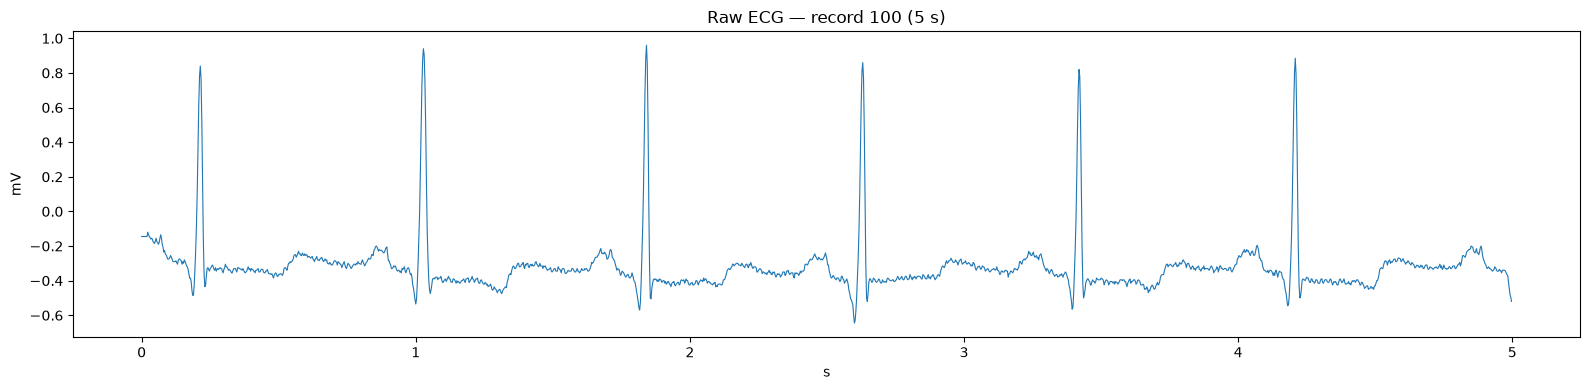

In [ ]:
beats = df[df["is_beat"]]
fig, ax = plt.subplots(1, 1, figsize=(16, 4))



sig = load_signal(100)
t = np.arange(5 * FS) / FS
ax.plot(t, sig[:5 * FS], lw=0.8); ax.set_title("Raw ECG — record 100 (5 s)")
ax.set_xlabel("s"); ax.set_ylabel("mV")
plt.tight_layout(); plt.show()

In [4]:
df.info()
display(df.describe(include="all"))
print(f"\n# columns (features) in the beat table: {df.shape[1]}  ->  {list(df.columns)}")

print("\nLargest Lyapunov exponent (Rosenstein) on a raw segment per record:")
rng = np.random.RandomState(0)
some = rng.choice(sorted(set(df['record']) - PACED), LYAP_N_RECORDS, replace=False)
for rec in some:
    seg = load_signal(rec)[:LYAP_SEG]
    lam = nolds.lyap_r(seg, emb_dim=10, lag=1, fit="poly")
    horizon = f"~{1/lam:,.0f} samples (~{1/lam/FS:.2f} s)" if lam > 0 else "n/a (λ≤0)"
    print(f"  rec {rec}: λ = {lam:+.4f}   predictability horizon {horizon}")
print(f"\nOur forecast horizon H_OUT = {H_OUT} samples ({H_OUT/FS:.3f} s).")

<class 'pandas.DataFrame'>
RangeIndex: 112647 entries, 0 to 112646
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   record      112647 non-null  int64  
 1   ann_idx     112647 non-null  int64  
 2   sample      112647 non-null  int64  
 3   time_s      112647 non-null  float64
 4   symbol      112647 non-null  str    
 5   is_beat     112647 non-null  bool   
 6   aami_class  112647 non-null  str    
 7   rr_prev_s   109446 non-null  float64
 8   rr_next_s   109446 non-null  float64
dtypes: bool(1), float64(3), int64(3), str(2)
memory usage: 7.2 MB


,record,ann_idx,sample,time_s,symbol,is_beat,aami_class,rr_prev_s,rr_next_s
count,112647.000000,112647.000000,112647.000000,112647.000000,112647,112647,112647,109446.000000,109446.000000
unique,NaN,NaN,NaN,NaN,23,2,6,NaN,NaN
top,NaN,NaN,NaN,NaN,N,True,N,NaN,NaN
freq,NaN,NaN,NaN,NaN,75052,109494,90631,NaN,NaN
mean,171.199055,1215.468783,325507.084805,904.186346,NaN,NaN,NaN,0.791472,0.791472
std,52.584055,749.569411,188257.494937,522.937486,NaN,NaN,NaN,0.379465,0.379465
min,100.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.250000,0.250000
25%,113.000000,586.000000,162156.500000,450.434750,NaN,NaN,NaN,0.655600,0.655600
50%,203.000000,1173.000000,325146.000000,903.183300,NaN,NaN,NaN,0.763900,0.763900
75%,217.000000,1773.000000,489226.500000,1358.962500,NaN,NaN,NaN,0.891700,0.891700



# columns (features) in the beat table: 9  ->  ['record', 'ann_idx', 'sample', 'time_s', 'symbol', 'is_beat', 'aami_class', 'rr_prev_s', 'rr_next_s']

Largest Lyapunov exponent (Rosenstein) on a raw segment per record:
  rec 213: λ = +0.0957   predictability horizon ~10 samples (~0.03 s)
  rec 223: λ = +0.0918   predictability horizon ~11 samples (~0.03 s)
  rec 209: λ = +0.0945   predictability horizon ~11 samples (~0.03 s)
  rec 106: λ = +0.0805   predictability horizon ~12 samples (~0.03 s)
  rec 114: λ = +0.0693   predictability horizon ~14 samples (~0.04 s)

Our forecast horizon H_OUT = 50 samples (0.139 s).


## 4. Wavelet denoising



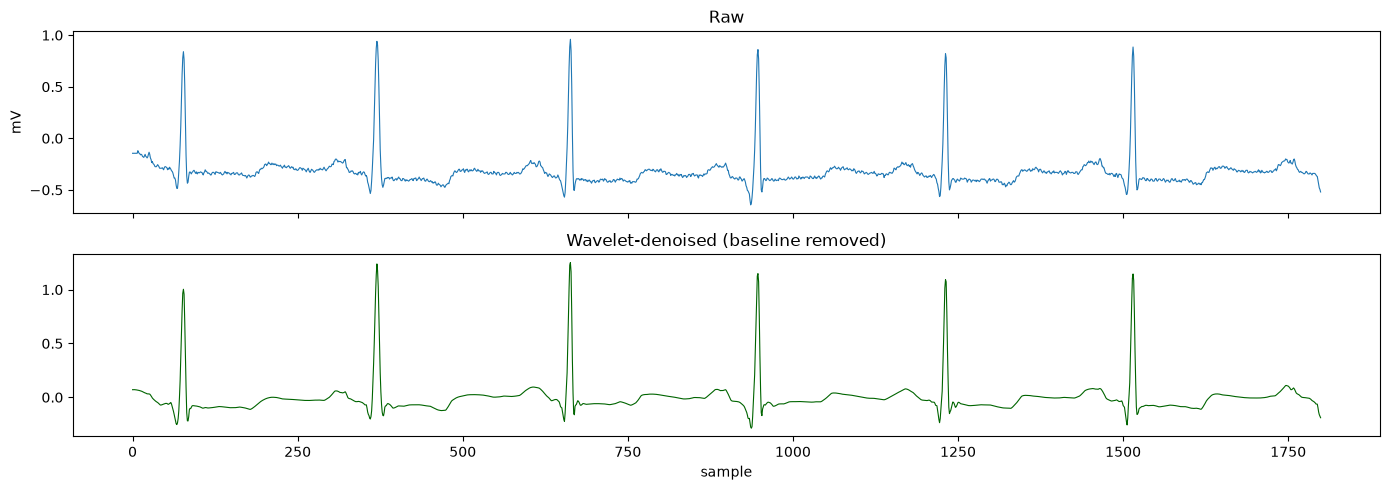

In [5]:
def wavelet_denoise(sig, wavelet=WAVELET, level=WT_LEVEL):
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745            # noise from finest detail
    thr = sigma * np.sqrt(2 * np.log(len(sig)))               # universal threshold
    coeffs[1:] = [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
    coeffs[0] = np.zeros_like(coeffs[0])                      # drop baseline wander
    out = pywt.waverec(coeffs, wavelet).astype(np.float32)
    return out[:len(sig)]

raw = load_signal(100)[:5 * FS]; den = wavelet_denoise(load_signal(100))[:5 * FS]
fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax[0].plot(raw, lw=0.8); ax[0].set_title("Raw"); ax[0].set_ylabel("mV")
ax[1].plot(den, lw=0.8, color="darkgreen"); ax[1].set_title("Wavelet-denoised (baseline removed)")
ax[1].set_xlabel("sample"); plt.tight_layout(); plt.show()

## 5. Per-record z-score normalization


preprocessed 44 records (paced excluded)


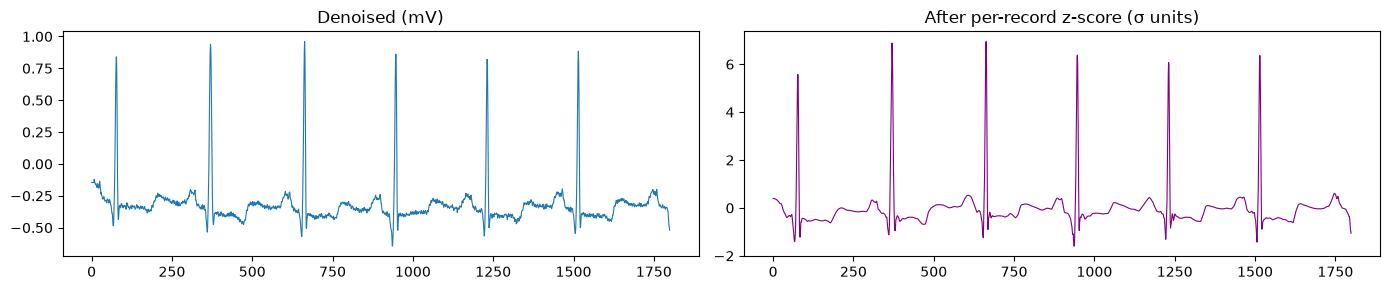

In [ ]:
def zscore(sig):
    return ((sig - sig.mean()) / (sig.std() + 1e-8)).astype(np.float32)

records = sorted(set(df["record"]) - PACED)
proc = {rec: zscore(wavelet_denoise(load_signal(rec))) for rec in records}
print(f"preprocessed {len(proc)} records (paced excluded)")


s = load_signal(100)[:5 * FS]
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].plot(s, lw=0.8); ax[0].set_title("Denoised (mV)")
ax[1].plot(proc[100][:5 * FS], lw=0.8, color="purple"); ax[1].set_title("After per-record z-score (σ units)")
plt.tight_layout(); plt.show()

## 6. Inter-patient split

Whole records go to exactly one split → the model forecasts **patients it never saw**.
Two schemes (toggle `SPLIT_MODE` in CONFIG):
- **`ratio`** — shuffle patients, 80 % / 10 % / 10 %.
- **`dechazal`** — the canonical DS1/DS2 benchmark (22 train / 22 test records), with the
  validation set carved from the last 4 records of DS1.

In [7]:
if SPLIT_MODE == "dechazal":
    DS1 = [101,106,108,109,112,114,115,116,118,119,122,124,201,203,205,207,208,209,215,220,223,230]
    DS2 = [100,103,105,111,113,117,121,123,200,202,210,212,213,214,219,221,222,228,231,232,233,234]
    train_recs, val_recs, test_recs = DS1[:-4], DS1[-4:], DS2      # val = last 4 of DS1
else:  # "ratio" -> 80/10/10 by patient
    perm = np.random.RandomState(42).permutation(records)
    n = len(perm); n_tr, n_va = int(0.8 * n), int(0.1 * n)
    train_recs = sorted(perm[:n_tr]); val_recs = sorted(perm[n_tr:n_tr + n_va]); test_recs = sorted(perm[n_tr + n_va:])

for name, recs in [("train", train_recs), ("val", val_recs), ("test", test_recs)]:
    sub = df[(df["record"].isin(recs)) & (df["is_beat"])]
    counts = sub["aami_class"].value_counts().to_dict()
    print(f"{name:5s}: {len(recs):2d} records  beats={len(sub):6d}  classes={counts}")

train: 35 records  beats= 80741  classes={'N': 71886, 'V': 5541, 'S': 2513, 'F': 786, 'Q': 15}
val  :  4 records  beats=  8286  classes={'N': 8096, 'S': 117, 'V': 68, 'F': 5}
test :  5 records  beats= 11706  classes={'N': 10143, 'V': 1400, 'S': 151, 'F': 12}


## 7. Forecasting windows (`L_IN → H_OUT`, sliding by `STRIDE`)

In [8]:
def make_windows(recs, cap=MAX_WINDOWS_PER_RECORD):
    '''Slide over each record: X = L_IN past samples, Y = next H_OUT samples.'''
    X, Y = [], []
    for rec in recs:
        sig = proc[rec]; taken = 0
        for s in range(0, len(sig) - L_IN - H_OUT, STRIDE):
            X.append(sig[s:s + L_IN]); Y.append(sig[s + L_IN:s + L_IN + H_OUT])
            taken += 1
            if cap is not None and taken >= cap: break
    return np.asarray(X, np.float32), np.asarray(Y, np.float32)

X_train, Y_train = make_windows(train_recs)
X_val,   Y_val   = make_windows(val_recs)
X_test,  Y_test  = make_windows(test_recs)
for n, X, Y in [("train", X_train, Y_train), ("val", X_val, Y_val), ("test", X_test, Y_test)]:
    print(f"{n:5s}: X {X.shape}  Y {Y.shape}")

train: X (10500, 720)  Y (10500, 50)
val  : X (1200, 720)  Y (1200, 50)
test : X (1500, 720)  Y (1500, 50)


## 8. TCN autoencoder — trained feature extractor still under development and search

epoch  1/10  reconstruction MSE 1.1046
epoch  2/10  reconstruction MSE 0.9604
epoch  3/10  reconstruction MSE 0.9548
epoch  4/10  reconstruction MSE 0.9540
epoch  5/10  reconstruction MSE 0.9535
epoch  6/10  reconstruction MSE 0.9533
epoch  7/10  reconstruction MSE 0.9527
epoch  8/10  reconstruction MSE 0.9514
epoch  9/10  reconstruction MSE 0.9506
epoch 10/10  reconstruction MSE 0.9502


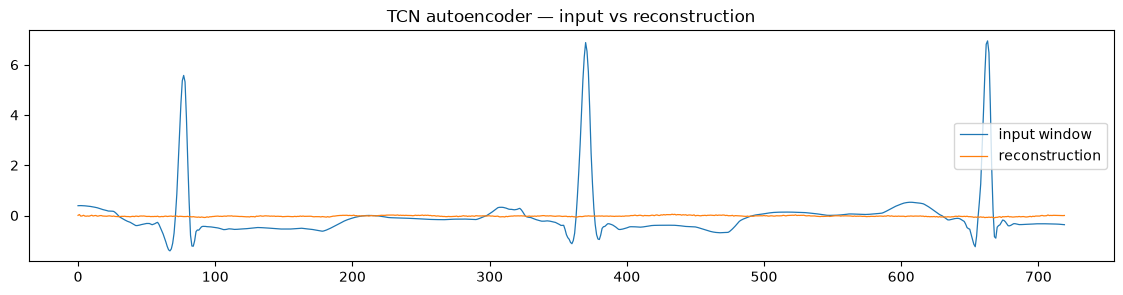

encoded features: (10500, 32) (1200, 32) (1500, 32)


In [9]:
class TCNAutoencoder(nn.Module):
    def __init__(self, L=L_IN, latent=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(                          # dilated causal-style TCN
            nn.Conv1d(1, 16, 7, padding=3, dilation=1), nn.ReLU(),
            nn.Conv1d(16, 32, 7, padding=6, dilation=2), nn.ReLU(),
            nn.Conv1d(32, 64, 7, padding=12, dilation=4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(64, latent))
        self.fc = nn.Sequential(nn.Linear(latent, 64 * 45), nn.ReLU())
        self.decoder = nn.Sequential(                          # 45 -> 90 -> 180 -> 360 -> 720
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(16, 8, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(8, 1, 4, stride=2, padding=1))
    def forward(self, x):
        z = self.encoder(x)
        r = self.decoder(self.fc(z).view(x.size(0), 64, 45))
        return r, z

dev = "cpu"
ae = TCNAutoencoder().to(dev)
opt = torch.optim.Adam(ae.parameters(), lr=LR); lossf = nn.MSELoss()
xt = torch.from_numpy(X_train).unsqueeze(1)               # (N,1,L_IN)

for ep in range(AE_EPOCHS):
    perm = torch.randperm(len(xt)); tot = 0.0
    for i in range(0, len(xt), BATCH):
        b = xt[perm[i:i + BATCH]].to(dev)
        opt.zero_grad(); rec, _ = ae(b); loss = lossf(rec, b)
        loss.backward(); opt.step(); tot += loss.item() * len(b)
    print(f"epoch {ep + 1:2d}/{AE_EPOCHS}  reconstruction MSE {tot / len(xt):.4f}")

# reconstruction sanity plot
ae.eval()
with torch.no_grad():
    ex = xt[:1].to(dev); rec, _ = ae(ex)
plt.figure(figsize=(14, 3))
plt.plot(ex.squeeze().numpy(), lw=0.9, label="input window")
plt.plot(rec.squeeze().numpy(), lw=0.9, label="reconstruction")
plt.title("TCN autoencoder — input vs reconstruction"); plt.legend(); plt.show()

@torch.no_grad()
def encode(X):
    return ae.encoder(torch.from_numpy(X).unsqueeze(1).to(dev)).cpu().numpy()

F_train, F_val, F_test = encode(X_train), encode(X_val), encode(X_test)
print("encoded features:", F_train.shape, F_val.shape, F_test.shape)

## 9. Finalize — datasets for the downstream models

Saved per split: **`X`** (raw input window, `720`), **`Y`** (forecast target, next `50`),
and **`F`** (the TCN encoder features, `LATENT_DIM`). The next models (Transformer / CNN)
will map either `X` or `F` → `Y`.

In [10]:
np.savez_compressed(os.path.join(OUT_DIR, "dataset.npz"),
    X_train=X_train, Y_train=Y_train, F_train=F_train,
    X_val=X_val,     Y_val=Y_val,     F_val=F_val,
    X_test=X_test,   Y_test=Y_test,   F_test=F_test)
torch.save(ae.encoder.state_dict(), os.path.join(OUT_DIR, "tcn_encoder.pt"))

print("Saved -> ", os.path.join(OUT_DIR, "dataset.npz"))
print("         ", os.path.join(OUT_DIR, "tcn_encoder.pt"))
print(f"\nDownstream models load dataset.npz and learn  X or F  ->  Y (next {H_OUT} samples).")
print(f"split={SPLIT_MODE} | train/val/test windows = {len(X_train)}/{len(X_val)}/{len(X_test)}")

Saved ->  outputs/forecasting/dataset.npz
          outputs/forecasting/tcn_encoder.pt

Downstream models load dataset.npz and learn  X or F  ->  Y (next 50 samples).
split=ratio | train/val/test windows = 10500/1200/1500
